# Fig. 4 — HDX–MS centroid and envelope observables before and after back exchange

Centroid uptake on the left, stacked isotopic envelopes on the right. Back exchange is applied at the pattern level (Appendix F).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

_here = os.getcwd()
_py = os.path.abspath(os.path.join(_here, '..', 'python'))
if _py not in sys.path:
    sys.path.insert(0, _py)

import hdx_env as H
import hdx_backexchange as BX
from hdx_env import (averagine_composition, natural_envelope,
                     mass_envelope, COLORS)
H.set_plot_style(use_tex=False)

PLOTS_DIR = os.path.abspath(os.path.join(_here, '..', 'figures'))
os.makedirs(PLOTS_DIR, exist_ok=True)

In [2]:
# ---------------------------------------------------------------------------
# Random EX2 peptide: heterogeneous k_int, P and retention beta.
# (Same parameter choices as backexchange.ipynb for direct comparability.)
# ---------------------------------------------------------------------------
rng = np.random.default_rng(20260519)

N = 8
P = tuple(range(N))

k_int = BX.random_kint(N,    log10_range=(0, 1), rng=rng)   # 1/s
pfact = BX.random_pfactors(N, log10_range=(2, 4), rng=rng)
beta  = BX.random_betas(N,   low=0.7, high=0.9, rng=rng)

model = BX.setup_uncoupled(pfact, k_int, k_total=1e4)

t       = np.logspace(-.22, 4.02, 425)
t_snaps = np.array([1.0, 1e1, 1e2, 1e3, 1e4])

# Subset survivals and uptake distributions on both grids
prob_bx,   prob_no_bx,   psi_X   = BX.envelope_with_backexchange(model, P, t,       beta)
prob_bx_s, prob_no_bx_s, psi_X_s = BX.envelope_with_backexchange(model, P, t_snaps, beta)

# Centroid and variance (closed-form, exact for any regime)
c_full = model.centroid(P, t)
v_full = model.variance(P, t)
c_bx   = BX.centroid_with_backexchange(P, t, psi_X, beta)
v_bx   = BX.variance_with_backexchange(P, t, psi_X, beta)
sd_full = np.sqrt(np.clip(v_full, 0, None))
sd_bx   = np.sqrt(np.clip(v_bx,   0, None))

print(f'<beta> = {beta.mean():.3f}    back-exchange fraction = {(1-beta).mean():.3f}')

<beta> = 0.772    back-exchange fraction = 0.228


## Figure

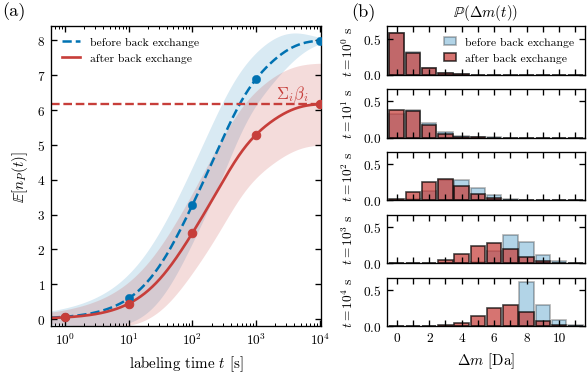

In [3]:
RED   = '#C73E3A'                   # softer red than the default vermillion
BLUE  = COLORS['uncoupled']
alpha_ideal = 0.3                   # transparency of the ideal background bars

# Natural isotope envelope of an averagine peptide of comparable mass
peptide_mass = 110.0 * N
nat_env = natural_envelope(averagine_composition(peptide_mass), n_peaks=12)
L_env   = N + len(nat_env) - 8
offs    = np.arange(L_env)

env_ex2 = mass_envelope(prob_no_bx_s, nat_env, n_peaks=L_env)
env_bx  = mass_envelope(prob_bx_s,    nat_env, n_peaks=L_env)
ymax    = max(env_ex2.max(), env_bx.max()) * 1.10

Ns = len(t_snaps)
fig = plt.figure(figsize=(5, 3.2))

# ---- left  : centroid uptake -----------------------------------------
gs_c = fig.add_gridspec(1, 1, left=0.10, right=0.55, top=0.94, bottom=0.16)
# ---- right : Ns rows of envelope panels ------------------------------
gs_r = fig.add_gridspec(Ns, 1, hspace=0.30,
                        left=0.66, right=0.99, top=0.94, bottom=0.16)

# ==================== LEFT: centroid uptake ============================
ax_c = fig.add_subplot(gs_c[0, 0])
ax_c.fill_between(t, c_full - sd_full, c_full + sd_full,
                  color=BLUE, alpha=0.15, lw=0)
ax_c.fill_between(t, c_bx - sd_bx, c_bx + sd_bx,
                  color=RED,  alpha=0.18, lw=0)
ax_c.plot(t, c_full, color=BLUE, ls='--', lw=1.5,
          label='before back exchange')
ax_c.plot(t, c_bx,   color=RED,             lw=1.6,
          label='after back exchange')
ax_c.axhline(float(np.sum(beta)), color=RED, lw=1.4, ls='--')

# scatter markers on the snapshot times — match the markers on the envelope rows
c_full_at_snap = model.centroid(P, t_snaps)
c_bx_at_snap   = BX.centroid_with_backexchange(P, t_snaps, psi_X_s, beta)
ax_c.scatter(t_snaps, c_full_at_snap,
             facecolor=BLUE, edgecolor=BLUE, s=26, lw=0.2, zorder=5,
             marker='o')
ax_c.scatter(t_snaps, c_bx_at_snap,
             facecolor=RED, edgecolor=RED, s=26, lw=0.6, zorder=5,
             marker='o')

ax_c.set_xscale('log')
ax_c.set_xlim(t[0], t[-1])
ax_c.set_ylim(-0.2, N + 0.4)
ax_c.set_xlabel(r'labeling time $t$ [s]')
ax_c.set_ylabel(r'$\mathbb{E}[n_P(t)]$')
ax_c.legend(loc='upper left', fontsize=7, handlelength=1.6, frameon=False)
ax_c.text(t[-1]*0.2, float(np.sum(beta)) + 0.16, r'${\Sigma}_i\beta_i$',
          color=RED, fontsize=10)
ax_c.text(-0.18, 1.02, '(a)', transform=ax_c.transAxes,
          fontsize=11, fontweight='bold', va='bottom', ha='left')

# ==================== RIGHT: stacked envelope rows =====================
x_ticks      = np.arange(0, L_env, 1)
x_ticklabels = [tk if tk % 2 == 0 else '' for tk in x_ticks]

for ti, tsnap in enumerate(t_snaps):
    ax_e = fig.add_subplot(gs_r[ti, 0])

    # background: ideal (before back exchange)
    ax_e.bar(offs, env_ex2[ti], width=0.9,
             color=BLUE, edgecolor='black', lw=1, alpha=alpha_ideal,
             label='before back exchange' if ti == 0 else None)
    # foreground: back-exchange-corrected
    ax_e.bar(offs, env_bx[ti], width=0.9,
             color=RED, edgecolor='black', lw=1, alpha=.72,
             label='after back exchange' if ti == 0 else None)

    ax_e.set_xticks(x_ticks, labels=x_ticklabels)
    ax_e.set_xlim(-0.6, L_env - 0.4)
    ax_e.set_ylim(0, ymax)
    ax_e.set_yticks([0, 0.5])

    if ti != Ns - 1:
        plt.setp(ax_e.get_xticklabels(), visible=False)
    else:
        ax_e.set_xlabel(r'$\Delta m$ [Da]')

    exp = int(round(np.log10(tsnap)))
    ax_e.set_ylabel(rf'$t=10^{{{exp}}}$ s', fontsize=8)
    if ti == 0:
        ax_e.text(-0.18, 1.10, '(b)', transform=ax_e.transAxes,
                  fontsize=11, fontweight='bold', va='bottom', ha='left')
        ax_e.set_title(r'$\mathbb{P}(\Delta m(t))$')
        ax_e.legend(loc='upper right', fontsize=7, handlelength=1.0,
                    frameon=False, ncol=1, columnspacing=1.0)

fig.savefig(os.path.join(PLOTS_DIR, 'fig4.pdf'),
            bbox_inches='tight')
plt.show()